In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
import matplotlib.pyplot as plt 

In [3]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\performance_on_simulated_data'

In [4]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [5]:
os.chdir(Path(notebook_dir).parents[3])

In [6]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [7]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'perf_sim_data6') 

In [8]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [13]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [9]:
adata_800 = {k: v.copy() for k, v in adata_dict.items() if '800' in k}
adata_1000 = {k: v.copy() for k, v in adata_dict.items() if '1000' in k}
adata_1200 = {k: v.copy() for k, v in adata_dict.items() if '1200' in k}

<Axes: >

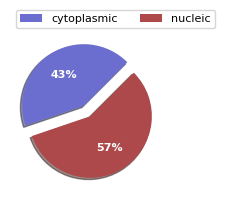

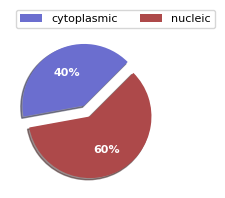

In [10]:
proportions_nuc_cyto(adata_800['adata_n_c_800obs_300genes_deterministic'])
proportions_nuc_cyto(adata_1000['adata_n_c_1000obs_300genes_deterministic'])
# proportions_nuc_cyto(adata_1200['adata_n_c_1200obs_300genes_deterministic'])

# Umaps 

In [11]:

def plot_velocity_embedding_streams_nc(adata_dict, color_option='true_t',n_obs = 800 , n_var = 300, mode = 'n_c'):
    """
    Plots velocity embedding streams for an AnnData dictionary containing only 'n_c' data,
    arranging the plots in a 2x2 grid with the velocity type as the title on each graph.

    Parameters:
    - adata_dict (dict): Dictionary with AnnData objects. Keys should follow the pattern 
                         'adata_n_c_800obs_300genes_{velocity_type}'.
    - color_option (str): Column name in AnnData.obs to color the plots. Default is 'true_t'.
    """
    # Create a figure with 2 rows and 2 columns of subplots
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # Adjust figsize as needed

    # List of velocity types and corresponding labels
    velocity_types = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    velocity_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Flatten axes array for easy indexing
    axes_flat = axes.flatten()

    # Loop over each velocity type and plot the corresponding subplots
    for i, (velocity_type, velocity_label) in enumerate(zip(velocity_types, velocity_labels)):
        ax = axes_flat[i]
        # Plot for Cytoplasmic-Nucleic data
        adata_key_nc = f'adata_{mode}_{n_obs}obs_{n_var}genes_{velocity_type}'
        if adata_key_nc in adata_dict:
            scv.pl.velocity_embedding_stream(
                adata_dict[adata_key_nc],
                basis='umap',
                color=color_option,
                ax=ax,
                show=False,
                title=velocity_label  # Set the velocity type as the title
            )
        else:
            # If the key is not in the dictionary, skip or handle appropriately
            print(f"Warning: {adata_key_nc} not found in adata_dict.")
            ax.set_visible(False)  # Hide the subplot if no data

        # Optionally, turn off x and y-axis labels to reduce clutter
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Remove any unused subplots if adata_dict has fewer than 4 entries
    total_plots = len(velocity_types)
    if len(axes_flat) > total_plots:
        for i in range(total_plots, len(axes_flat)):
            axes_flat[i].set_visible(False)

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Add a main title for the entire figure
    fig.suptitle('Velocity Embedding Streams by Model', fontsize=18, y=0.995)

    # Show the plot
    plt.show()


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


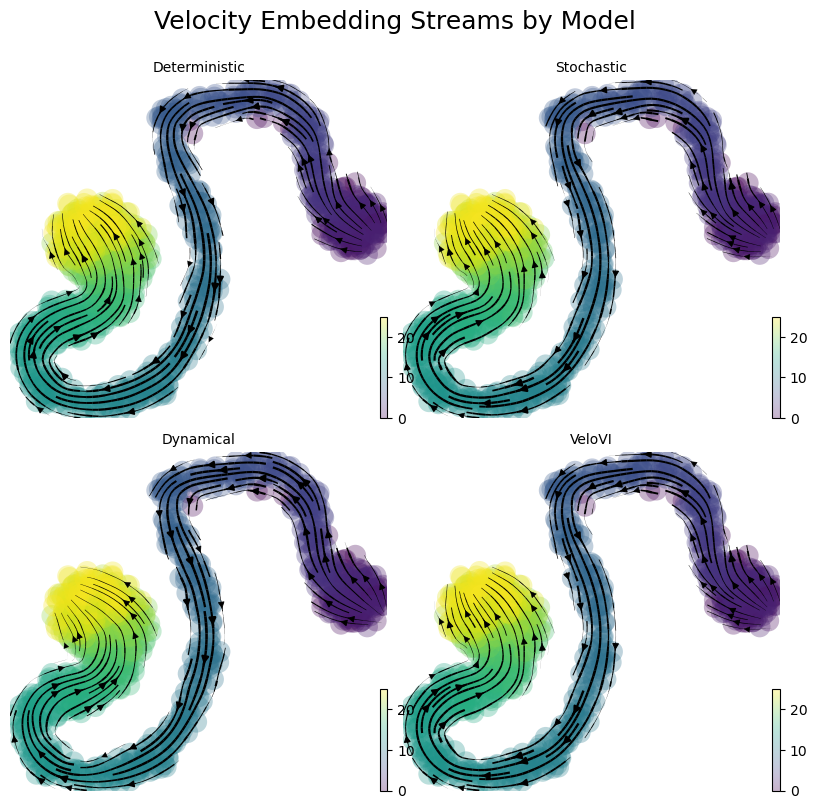

In [12]:
plot_velocity_embedding_streams_nc(adata_dict=adata_dict,n_obs=1000,n_var=300,mode='n_c',color_option='true_t')

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


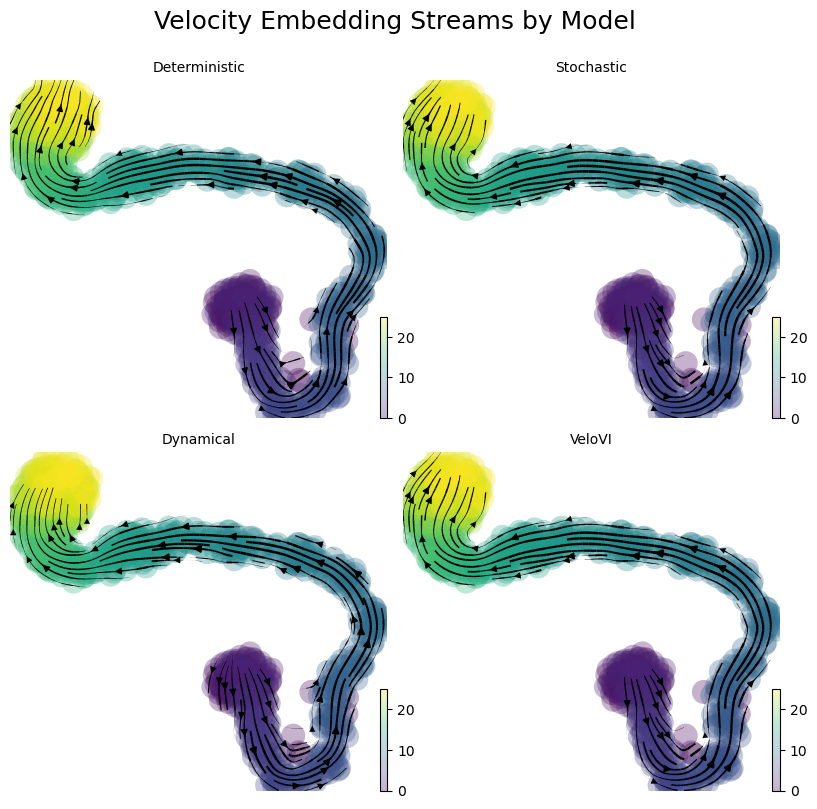

In [13]:
plot_velocity_embedding_streams_nc(adata_dict=adata_dict,n_obs=800,n_var=300,mode='n_c')

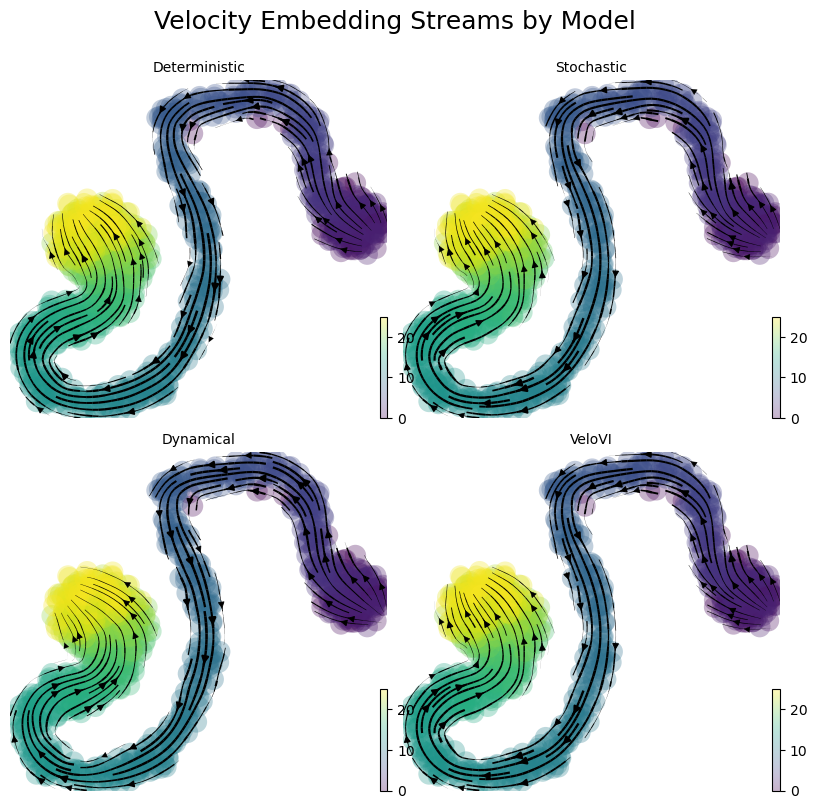

In [14]:
plot_velocity_embedding_streams_nc(adata_dict=adata_dict,n_obs=1000,n_var=300,mode='n_c')

# Metrics 

## Velocity Confidence


- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.

In [20]:
adata_dict.keys()

dict_keys(['adata_n_c_1000obs_300genes_deterministic', 'adata_n_c_1000obs_300genes_dynamical', 'adata_n_c_1000obs_300genes_stochastic', 'adata_n_c_1000obs_300genes_velovi', 'adata_n_c_1200obs_300genes_deterministic', 'adata_n_c_1200obs_300genes_dynamical', 'adata_n_c_1200obs_300genes_stochastic', 'adata_n_c_1200obs_300genes_velovi', 'adata_n_c_800obs_300genes_deterministic', 'adata_n_c_800obs_300genes_dynamical', 'adata_n_c_800obs_300genes_stochastic', 'adata_n_c_800obs_300genes_velovi'])

In [15]:
import scvelo as scv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_velocity_confidences(adatas):
    """
    Computes velocity confidences for each AnnData object in the dictionary and plots them using a violin plot.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_n_c_obs_genes_velocitytype',
                     and values are AnnData objects.

    The keys should follow this format:
    - 'adata_n_c_800obs_300genes_deterministic'
    """

    # Initialize an empty list to collect data for plotting
    plot_data = []

    # Loop through each AnnData object in the dictionary
    for key, adata in adatas.items():
        # Compute velocity confidence if not already computed
        if 'velocity_confidence' not in adata.obs:
            scv.tl.velocity_confidence(adata)

        # Extract velocity confidences from adata.obs
        velocity_confidence = adata.obs['velocity_confidence'].values

        # Parse the key to extract metadata
        # Key format: 'adata_n_c_800obs_300genes_deterministic'
        parts = key.split('_')
        # Extract observation count (e.g., '800obs')
        obs_count = parts[3]  # Assuming '800obs' is at index 3
        # Remove 'obs' to get the numeric value
        obs_count_value = int(obs_count.replace('obs', ''))

        # Extract velocity model type (e.g., 'deterministic', 'stochastic', etc.)
        velocity_type = parts[-1]

        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        # Create a DataFrame for this adata
        df = pd.DataFrame({
            'velocity_confidence': velocity_confidence,
            'velocity_type': velocity_type,
            'velocity_type_label': velocity_type_label,
            'obs_count': obs_count_value
        })

        # Append to the list
        plot_data.append(df)

    # Concatenate all DataFrames into one
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    # Corresponding labels
    velocity_type_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Map velocity_type to categorical type with specified order
    plot_df['velocity_type'] = pd.Categorical(
        plot_df['velocity_type'],
        categories=velocity_type_order,
        ordered=True
    )
    # Ensure the labels are in the same order
    plot_df['velocity_type_label'] = pd.Categorical(
        plot_df['velocity_type_label'],
        categories=velocity_type_labels,
        ordered=True
    )

    # Sort observation counts for consistent plotting
    obs_count_order = sorted(plot_df['obs_count'].unique())
    obs_count_labels = [f'{count} cells' for count in obs_count_order]

    # Map obs_count to categorical type with specified order
    plot_df['obs_count'] = pd.Categorical(
        plot_df['obs_count'],
        categories=obs_count_order,
        ordered=True
    )

    # Now, plot using seaborn

    # Set up the figure and axes
    fig, ax = plt.subplots(figsize=(12, 6))

    # Create a violin plot with nested grouping by velocity type and observation count
    sns.violinplot(
        x='velocity_type_label',
        y='velocity_confidence',
        hue='obs_count',
        data=plot_df,
        palette='Set2',
        order=velocity_type_labels,
        hue_order=obs_count_order,
        split=False,
        scale='width',
        inner='quartile',
        ax=ax
    )

    # Add vertical lines to separate velocity types
    x_positions = ax.get_xticks()
    for x in x_positions[1:]:
        ax.axvline(x=x - 0.5, color='gray', linestyle='--', linewidth=1)

    # Adjust legend labels
    handles, labels = ax.get_legend_handles_labels()
    obs_count_labels = [f'{int(label)} cells' for label in labels]
    ax.legend(handles=handles, labels=obs_count_labels, title='Observation Count', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title('Velocity Confidence by RNA Velocity Model and Observation Count')
    plt.xlabel('RNA Velocity Model')
    plt.ylabel('Velocity Confidence')
    plt.tight_layout()
    plt.show()


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length'

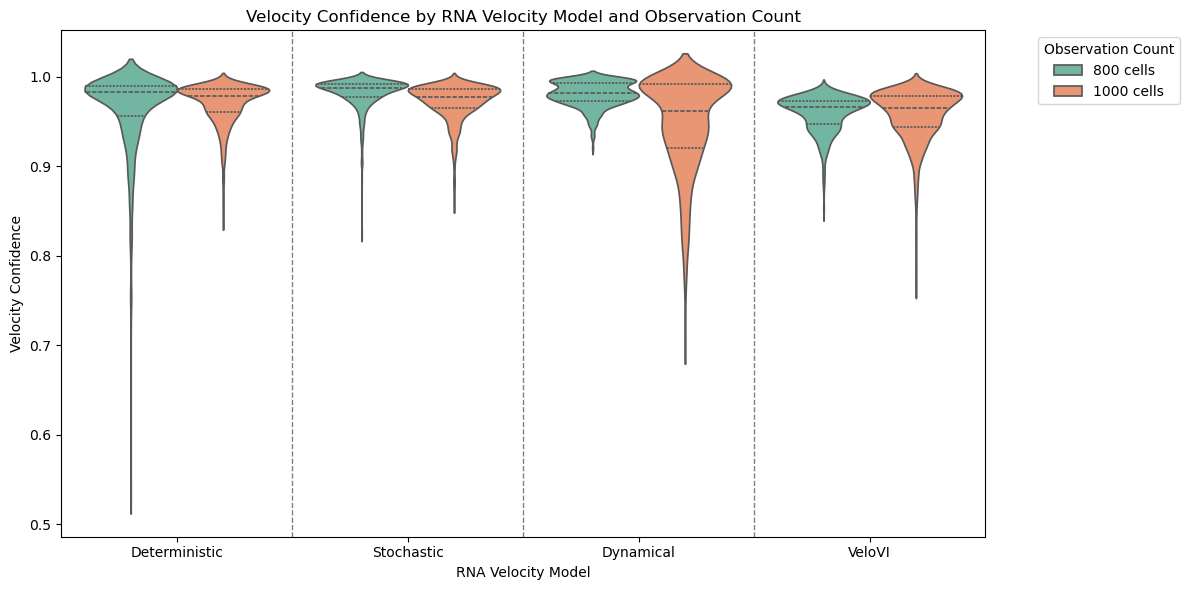

In [16]:
plot_velocity_confidences(adata_dict)

## velocity Correlations (by_gene)

# Check the important genes 

In [23]:
for adata_name, adata in adata_dict.items():
    scv.tl.rank_velocity_genes(adata,groupby='leiden',min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
   

In [24]:
dfs = scv.get_df(adata_dict['adata_n_c_800obs_300genes_dynamical'].uns['rank_velocity_genes']['names'])
dfs.tail(5)

,0,1,2,3,4,5,6,7,8
95,52,157,11,153,25,116,65,266,189
96,134,187,30,274,144,222,71,295,290
97,137,292,104,234,101,151,234,100,291
98,249,229,167,88,238,175,200,164,274
99,119,155,187,189,112,157,291,281,95


In [25]:
dfn = scv.get_df(adata_dict['adata_n_c_800obs_300genes_deterministic'].uns['rank_velocity_genes']['names'])
dfn.head(5)

,0,1,2,3,4,5,6,7,8
0,227,166,111,75,80,276,111,234,111
1,75,82,223,295,287,223,276,175,276
2,94,262,18,95,33,18,52,113,18
3,238,283,276,268,11,52,18,80,188
4,295,126,52,43,226,226,122,197,223


In [26]:
dfs['8'].tail()

95    189
96    290
97    291
98    274
99     95
Name: 8, dtype: object

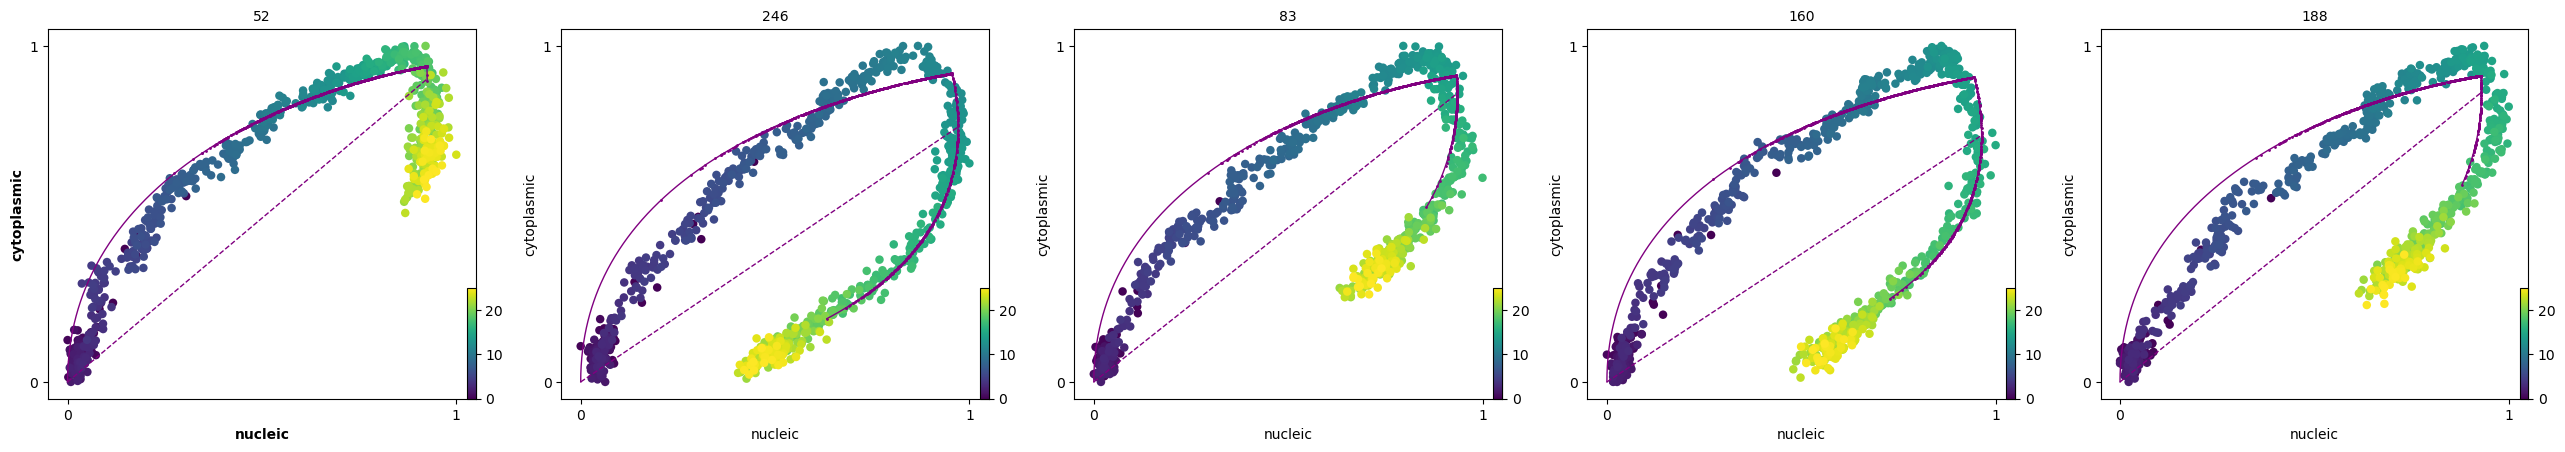

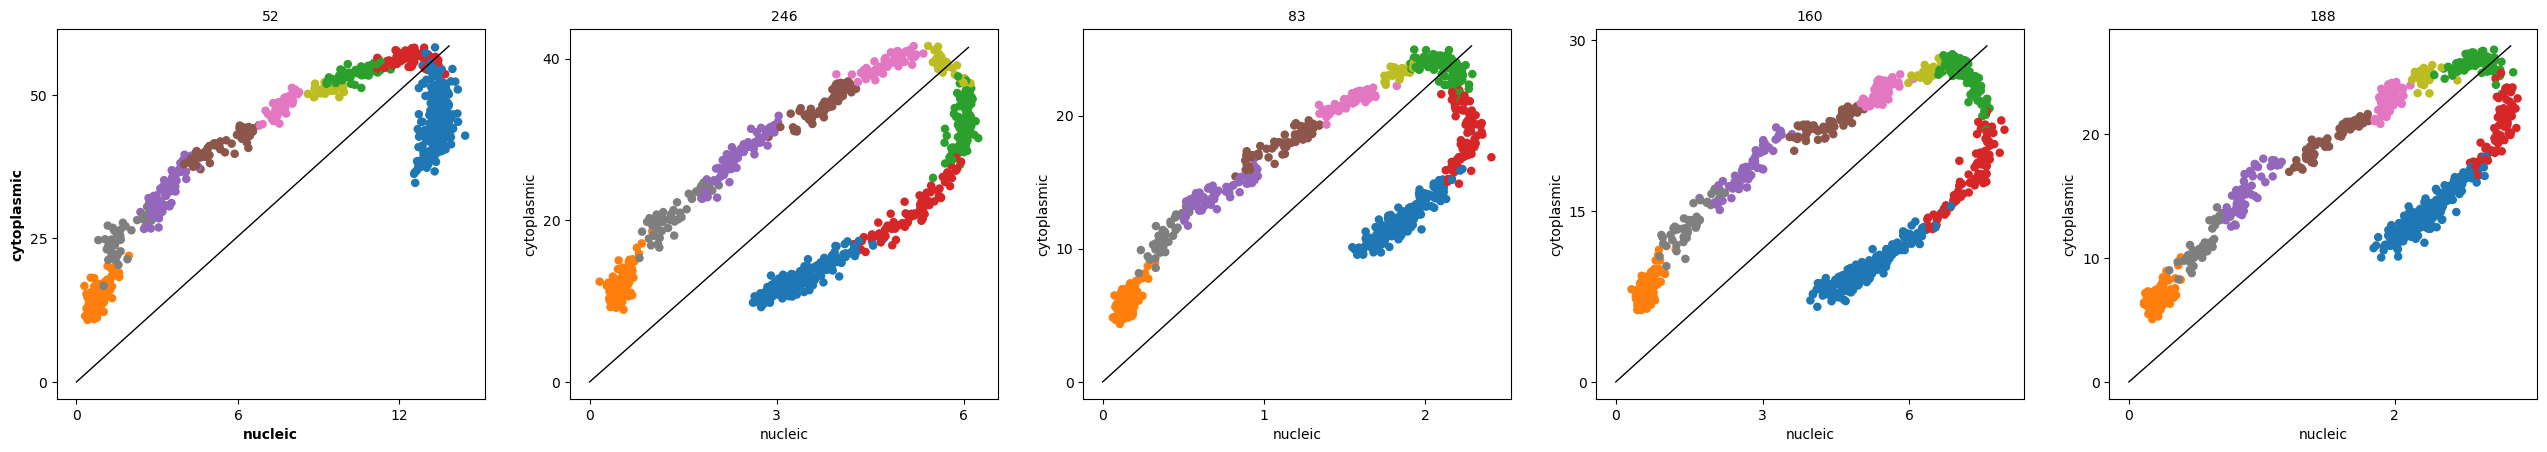

In [27]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_velovi'], dfs['8'][:5], ylabel='cytoplasmic',xlabel='nucleic', color='true_t')
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_deterministic'], dfs['8'][:5], ylabel='cytoplasmic',xlabel='nucleic', color= 'leiden')

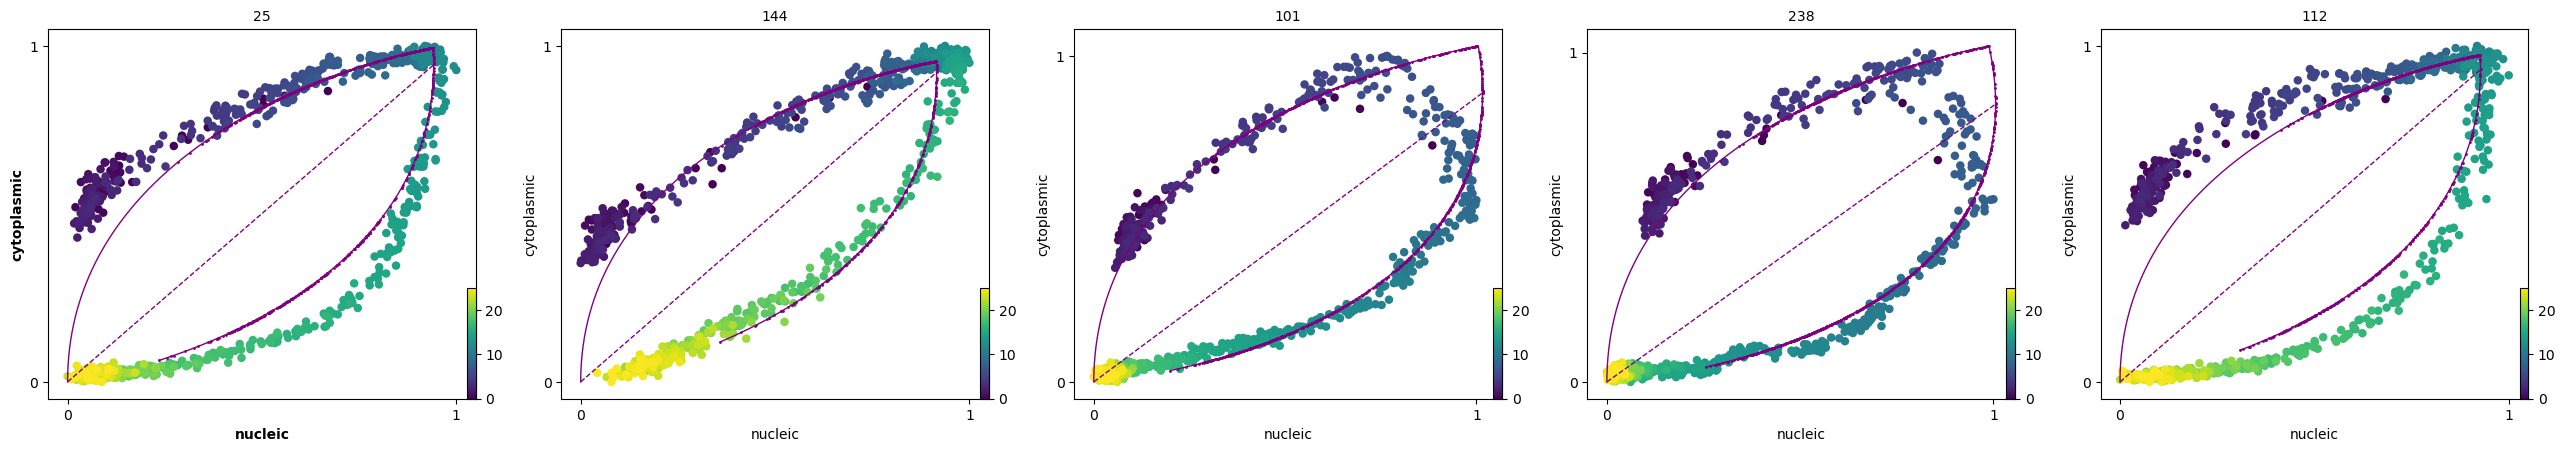

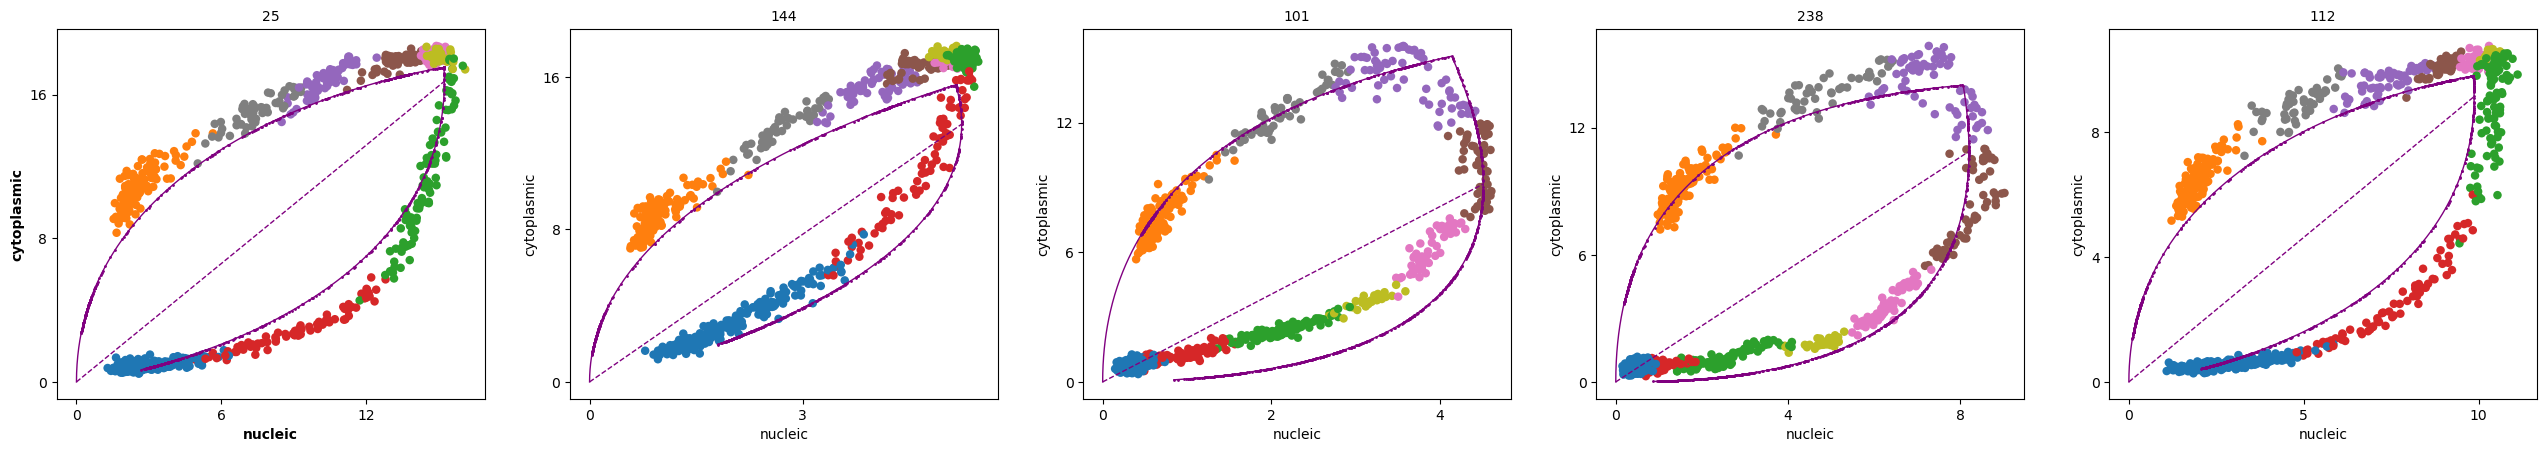

In [28]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_velovi'], dfs['4'].tail(), ylabel='cytoplasmic',xlabel='nucleic', color='true_t')
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_dynamical'], dfs['4'].tail(), ylabel='cytoplasmic',xlabel='nucleic', color= 'leiden')

## Pairwise correlations 

In [17]:
import pandas as pd
import numpy as np

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes pairwise correlations between velocity matrices of AnnData objects
    that have the same observation counts.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype',
                     and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A nested dictionary where each observation count is a key, and the value is
                           another dictionary with velocity types as keys and lists of correlation coefficients.
                           Each correlation list contains all pairwise correlations (not averaged).
    - mean_correlations (dict): A nested dictionary with observation counts as keys and DataFrames of mean pairwise
                                correlations between models as values.
    """

    # Collect all unique observation counts
    obs_counts = set()
    for key in adatas.keys():
        parts = key.split('_')
        obs_part = parts[3]  # e.g., '800obs'
        obs_count = obs_part.replace('obs', '')
        obs_counts.add(obs_count)

    # Initialize dictionaries to store correlations
    correlations = {}        # Store all individual correlations
    mean_correlations = {}   # Store mean correlations in a matrix

    for obs_count in obs_counts:
        # Find all AnnData objects with the same observation count
        adata_keys = [key for key in adatas.keys() if f'_{obs_count}obs_' in key]
        adata_dict = {key: adatas[key] for key in adata_keys}

        # Extract velocity types for labeling
        velocity_types = []
        for key in adata_keys:
            parts = key.split('_')
            velocity_type = parts[-1]
            velocity_types.append(velocity_type)

        # Initialize DataFrame to store mean correlations between models
        corr_matrix = pd.DataFrame(index=velocity_types, columns=velocity_types, dtype=float)
        
        # Dictionary to store all pairwise correlations for this obs_count
        all_corrs_for_obs = {vt: {} for vt in velocity_types}

        # Compute pairwise correlations between models
        for i, key1 in enumerate(adata_keys):
            adata1 = adatas[key1]
            if 'velocity' not in adata1.layers:
                print(f"Velocity not found in {key1}. Skipping.")
                continue

            # Extract velocity matrix
            velo1 = pd.DataFrame(
                adata1.layers['velocity'],
                index=adata1.obs_names,
                columns=adata1.var_names
            )

            for j, key2 in enumerate(adata_keys[i:], i):
                adata2 = adatas[key2]
                if 'velocity' not in adata2.layers:
                    print(f"Velocity not found in {key2}. Skipping.")
                    continue

                # Extract velocity matrix
                velo2 = pd.DataFrame(
                    adata2.layers['velocity'],
                    index=adata2.obs_names,
                    columns=adata2.var_names
                )

                # Ensure DataFrames are aligned
                # velo1_aligned, velo2_aligned = velo1.align(velo2, join='inner', axis=0)
                # velo1_aligned, velo2_aligned = velo1_aligned.align(velo2_aligned, join='inner', axis=1)

                # Compute correlations
                cross_corrs = []
                if mode == 'by_cell':
                    # Compute correlation by cell (across genes)
                    for idx in velo1.index:
                        v1 = velo1.loc[idx].values
                        v2 = velo2.loc[idx].values
                        mask = ~np.isnan(v1) & ~np.isnan(v2)
                        if np.sum(mask) > 0:
                            corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                            cross_corrs.append(corr)

                elif mode == 'by_gene':
                    # Compute correlation by gene (across cells)
                    for col in velo1.columns:
                        v1 = velo1[col].values
                        v2 = velo2[col].values
                        mask = ~np.isnan(v1) & ~np.isnan(v2)
                        if np.sum(mask) > 0:
                            corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                            cross_corrs.append(corr)
                else:
                    print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                    return None

                # Store all individual correlations
                vtype1 = key1.split('_')[-1]
                vtype2 = key2.split('_')[-1]
                all_corrs_for_obs[vtype1][vtype2] = cross_corrs
                all_corrs_for_obs[vtype2][vtype1] = cross_corrs  # Symmetric matrix

                # Calculate and store mean correlation for the pair
                mean_corr = np.nanmean(cross_corrs)
                corr_matrix.loc[vtype1, vtype2] = mean_corr
                corr_matrix.loc[vtype2, vtype1] = mean_corr  # Symmetric matrix

        correlations[obs_count] = all_corrs_for_obs
        mean_correlations[obs_count] = corr_matrix

    return correlations, mean_correlations


In [18]:
a,b = compute_velocity_correlations(adata_dict,mode='by_cell')
c,d = compute_velocity_correlations(adata_dict,mode='by_gene')

In [19]:
def get_lowest_correlated_genes(correlations, obs_count, model1, model2, n=5):
    """
    Retrieves the gene names with the lowest correlations between two models.

    Parameters:
    - correlations (dict): The dictionary containing all correlation values.
    - obs_count (str): The observation count (e.g., '800', '1000', or '1200').
    - model1 (str): The first model to compare (e.g., 'deterministic').
    - model2 (str): The second model to compare (e.g., 'stochastic').
    - n (int): The number of lowest correlations to retrieve.

    Returns:
    - list of tuples: Each tuple contains a gene index and its correlation value.
    """
    # Extract the correlation list for the specified models and observation count
    correlation_list = correlations[obs_count][model1][model2]

    # Sort correlations and get the indices of the n lowest values
    lowest_indices = np.argsort(correlation_list)[:n]
    lowest_correlations = [(i, correlation_list[i]) for i in lowest_indices]

    return lowest_correlations


In [22]:
get_lowest_correlated_genes(c,'800','deterministic','velovi')

[(214, -0.9398235814345725),
 (61, -0.903047591826294),
 (64, -0.8635240951974696),
 (65, -0.652546845912712),
 (92, -0.6439409121035702)]

In [21]:
adata_800['adata_n_c_800obs_300genes_dynamical'].obs.iloc[577]

true_t                            17.68
n_counts                    5635.735559
leiden                                2
velocity_self_transition       0.032503
Name: 577, dtype: object

In [ ]:
adata_800['adata_n_c_800obs_300genes_dynamical']

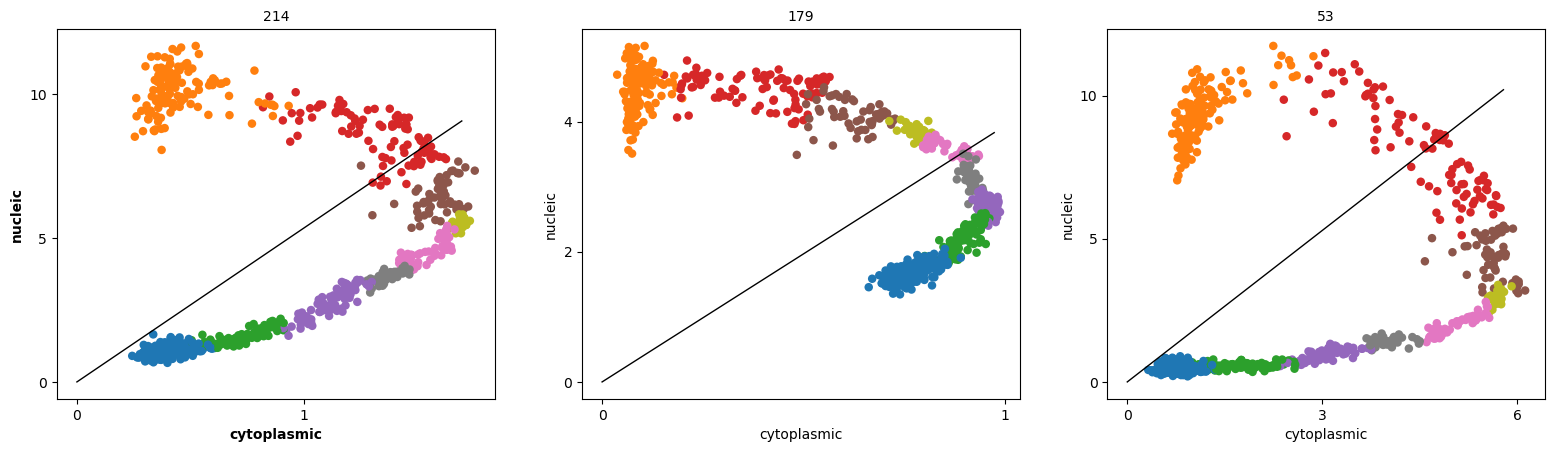

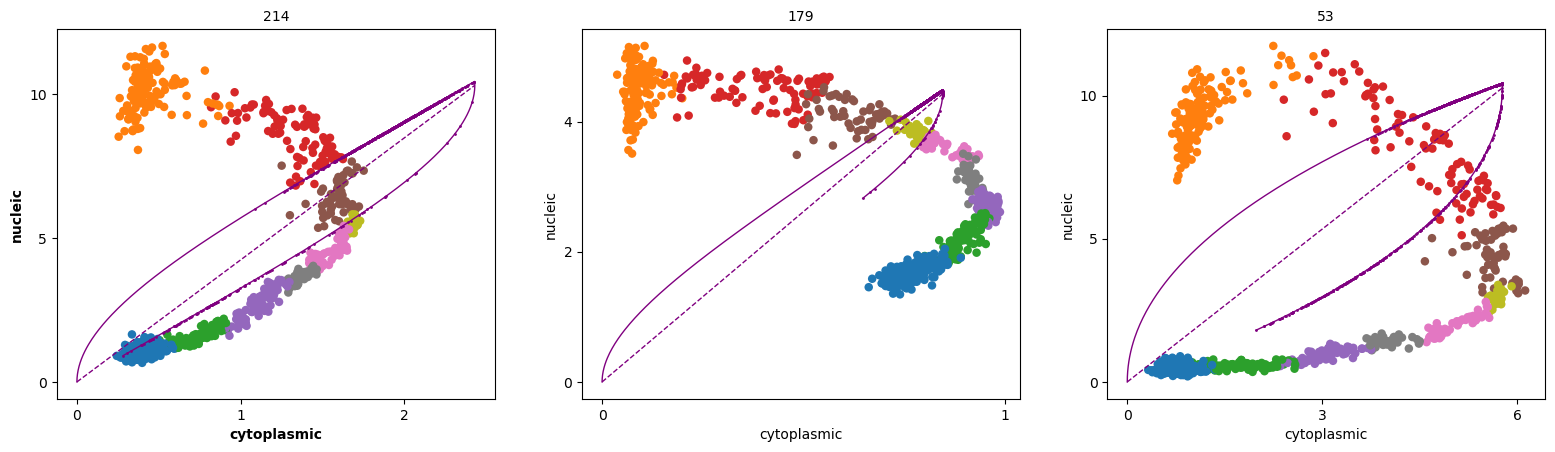

In [23]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_deterministic'], basis = ['214','179','53'],xlabel='cytoplasmic',ylabel='nucleic', color= 'leiden')
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_velovi'], basis = ['214','179','53'], xlabel='cytoplasmic',ylabel='nucleic', color= 'leiden')

In [24]:
cor_by_cell= velocity_mean_correlation(adata_800,mode='by_cell')
corr_by_gene = velocity_mean_correlation(adata_800,mode='by_gene')

cor_by_cell_1= velocity_mean_correlation(adata_1000,mode='by_cell')
corr_by_gene_1 = velocity_mean_correlation(adata_1000,mode='by_gene')

# cor_by_cell_12= velocity_mean_correlation(adata_1200,mode='by_cell')
# corr_by_gene_12 = velocity_mean_correlation(adata_1200,mode='by_gene')

In [25]:
name_mapping = {}

# Define data type mapping
data_type_map = {
    'n_c': '',
    's_u': 'splicing'
}

# Loop over each name in the index (and columns)
for name in cor_by_cell.index:
    parts = name.split('_')
    # Extract data type (e.g., 'n_c' or 's_u')
    data_type = parts[1] + '_' + parts[2]
    data_type_label = data_type_map.get(data_type, data_type)
    
    # Extract velocity model (e.g., 'deterministic', 'stochastic', etc.)
    velocity_model = parts[5]
    # Capitalize the velocity model name
    velocity_model_label = velocity_model.capitalize()
    
    # Combine to form the new label
    new_label = f"{velocity_model_label} {data_type_label}"
    
    # Add to the mapping
    name_mapping[name] = new_label



In [26]:
# Rename the index and columns using the mapping
corr_by_cell = cor_by_cell.rename(index=name_mapping, columns=name_mapping)
corr_by_gene = corr_by_gene.rename(index=name_mapping, columns=name_mapping)
# corr_by_cell_1 = cor_by_cell_1.rename(index=name_mapping_1, columns=name_mapping_1)
# corr_by_gene_1 = corr_by_gene_1.rename(index=name_mapping_1, columns=name_mapping_1)
# corr_by_cell_12 = cor_by_cell_12.rename(index=name_mapping_12, columns=name_mapping_12)
# corr_by_gene_12 = corr_by_gene_12.rename(index=name_mapping_12, columns=name_mapping_12)

In [118]:
b

{'800':                deterministic  dynamical  stochastic    velovi
 deterministic       1.000000   0.845783    0.990298  0.927532
 dynamical           0.845783   1.000000    0.824172  0.895702
 stochastic          0.990298   0.824172    1.000000  0.918114
 velovi              0.927532   0.895702    0.918114  1.000000,
 '1000':                deterministic  dynamical  stochastic    velovi
 deterministic       1.000000   0.837624    0.990731  0.928254
 dynamical           0.837624   1.000000    0.815577  0.879197
 stochastic          0.990731   0.815577    1.000000  0.917147
 velovi              0.928254   0.879197    0.917147  1.000000,
 '1200':                deterministic  dynamical  stochastic    velovi
 deterministic       1.000000   0.830088    0.991506  0.916033
 dynamical           0.830088   1.000000    0.801618  0.883546
 stochastic          0.991506   0.801618    1.000000  0.907751
 velovi              0.916033   0.883546    0.907751  1.000000}

In [120]:
corr_by_gene

,Deterministic in situ,Dynamical in situ,Stochastic in situ,Velovi in situ
Deterministic in situ,1.000000,0.845783,0.990298,0.927532
Dynamical in situ,0.845783,1.000000,0.824172,0.895702
Stochastic in situ,0.990298,0.824172,1.000000,0.918114
Velovi in situ,0.927532,0.895702,0.918114,1.000000


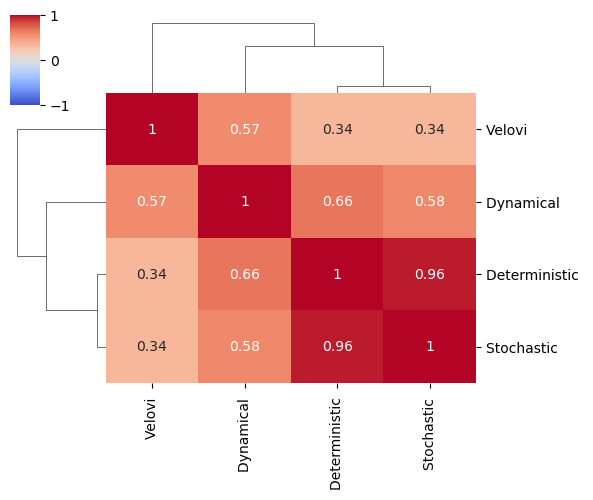

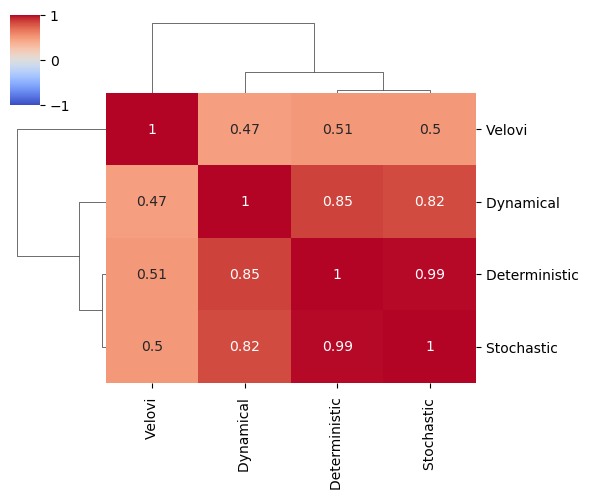

In [27]:
sns.clustermap(corr_by_cell, cmap='coolwarm', annot=True, figsize=(6, 5), vmin=-1, vmax=1)

sns.clustermap(corr_by_gene, cmap='coolwarm', annot=True, figsize=(6, 5), vmin=-1, vmax=1)

In [83]:
corr_by_cell

,Deterministic,Dynamical,Stochastic,Velovi
Deterministic,1.000000,0.661752,0.970772,0.417242
Dynamical,0.661752,1.000000,0.635537,0.387891
Stochastic,0.970772,0.635537,1.000000,0.421137
Velovi,0.417242,0.387891,0.421137,1.000000


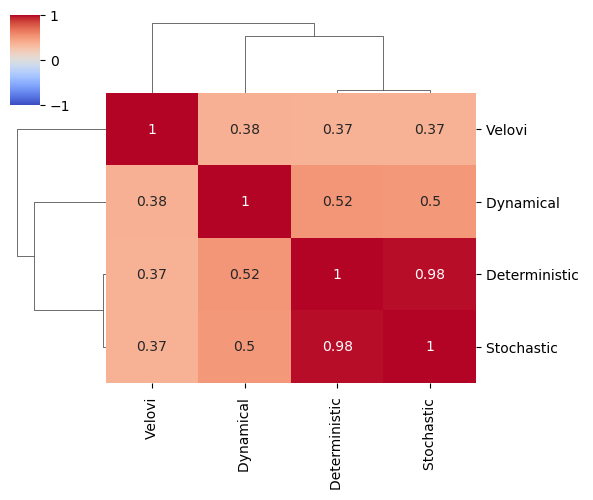

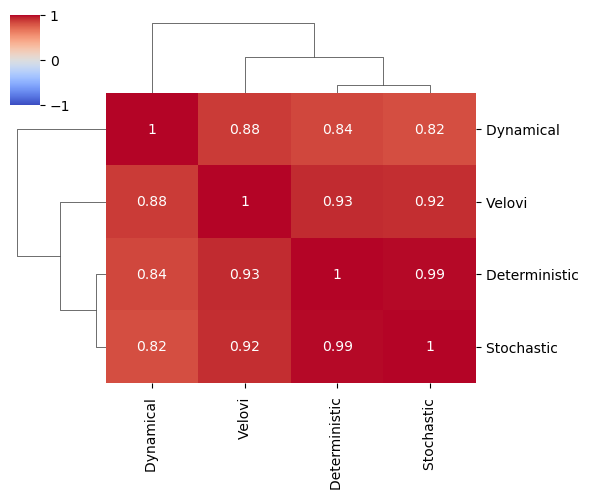

In [54]:
sns.clustermap(corr_by_cell_1, cmap='coolwarm', annot=True, figsize=(6, 5), vmin=-1, vmax=1)

sns.clustermap(corr_by_gene_1, cmap='coolwarm', annot=True, figsize=(6, 5), vmin=-1, vmax=1)

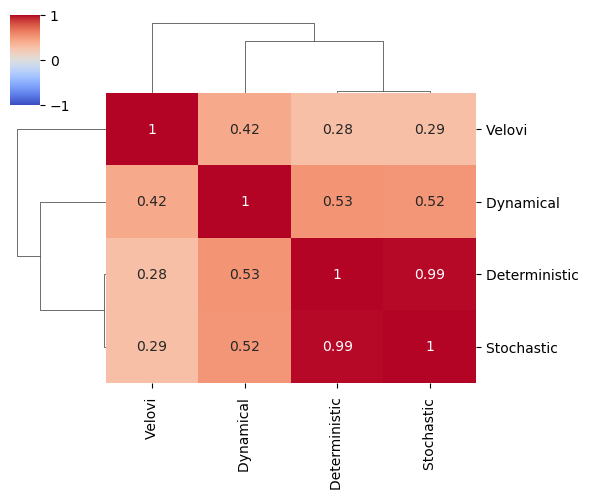

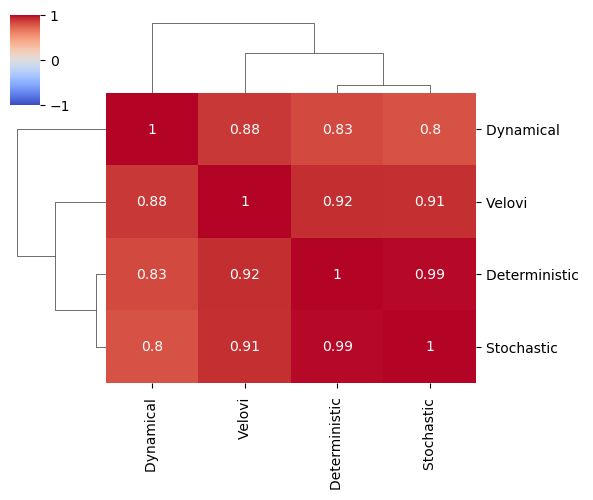

In [55]:
sns.clustermap(corr_by_cell_12, cmap='coolwarm', annot=True, figsize=(6, 5), vmin=-1, vmax=1)

sns.clustermap(corr_by_gene_12, cmap='coolwarm', annot=True, figsize=(6, 5), vmin=-1, vmax=1)

# True Velocity 

In [70]:
adata_dict['adata_n_c_800obs_299genes_deterministic'].layers['unspliced']

array([[1.81722992, 1.56308764, 2.01075246, ..., 0.95538787, 1.32792689,
        1.13935469],
       [1.77093825, 1.66298263, 1.72795493, ..., 1.33297418, 1.27662294,
        1.27206636],
       [2.47989471, 1.49536966, 1.39978413, ..., 1.25730886, 1.20639003,
        1.43580247],
       ...,
       [3.50312538, 0.40623056, 0.25894864, ..., 1.33378389, 1.57732125,
        1.41333048],
       [2.36750187, 0.52160162, 0.55362766, ..., 1.12886254, 1.29601308,
        1.39856427],
       [3.10708047, 0.56845825, 0.41965906, ..., 1.32580748, 1.5155674 ,
        1.54063667]])

In [72]:
adata_dict['adata_n_c_800obs_299genes_deterministic'].var['true_beta']

0      0.089248
1      0.146334
2      0.166089
3      0.198880
4      0.058292
         ...   
294    0.116113
295    0.059658
296    0.158353
297    0.156721
298    0.191188
Name: true_beta, Length: 299, dtype: float64

In [80]:
adata = adata_dict['adata_n_c_800obs_299genes_deterministic']

In [79]:
adata_dict['adata_n_c_800obs_299genes_deterministic'].layers['spliced'].shape

(433, 299)

In [84]:
import numpy as np
import pandas as pd

def pearson_correlation_matrices(matrix1, matrix2, mode='by_row'):
    """
    Computes Pearson correlation between two matrices either by row or by column.

    Parameters:
    - matrix1, matrix2: Two matrices (NumPy arrays or DataFrames) with the same shape.
    - mode: 'by_row' or 'by_column' to specify the direction for calculating correlations.

    Returns:
    - correlations: List of Pearson correlation coefficients for each row or column.
    """
    # Ensure matrices are in the right shape and format (convert to numpy if DataFrame)
    if isinstance(matrix1, pd.DataFrame):
        matrix1 = matrix1.values
    if isinstance(matrix2, pd.DataFrame):
        matrix2 = matrix2.values

    # Check if shapes are compatible
    if matrix1.shape != matrix2.shape:
        raise ValueError("Both matrices must have the same shape.")

    # Initialize list to store correlation coefficients
    correlations = []

    # Correlation by row (across columns)
    if mode == 'by_row':
        for i in range(matrix1.shape[0]):  # Loop through each row
            row1 = matrix1[i, :]
            row2 = matrix2[i, :]
            # Mask NaNs if present
            mask = ~np.isnan(row1) & ~np.isnan(row2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(row1[mask], row2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    # Correlation by column (across rows)
    elif mode == 'by_column':
        for j in range(matrix1.shape[1]):  # Loop through each column
            col1 = matrix1[:, j]
            col2 = matrix2[:, j]
            # Mask NaNs if present
            mask = ~np.isnan(col1) & ~np.isnan(col2)
            if np.sum(mask) > 0:
                corr = np.corrcoef(col1[mask], col2[mask])[0, 1]
                correlations.append(corr)
            else:
                correlations.append(np.nan)  # Append NaN if no valid data

    else:
        raise ValueError("Invalid mode. Use 'by_row' or 'by_column'.")

    return correlations


In [147]:
import numpy as np

def cosine_similarity_matrices(matrix1, matrix2, mode='by_row'):
    """
    Computes cosine similarity between two matrices either by row or by column.

    Parameters:
    - matrix1, matrix2: Two matrices (NumPy arrays or DataFrames) with the same shape.
    - mode: 'by_row' or 'by_column' to specify the direction for calculating similarities.

    Returns:
    - similarities: List of cosine similarity values for each row or column.
    """
    # Ensure matrices are NumPy arrays
    if isinstance(matrix1, pd.DataFrame):
        matrix1 = matrix1.values
    if isinstance(matrix2, pd.DataFrame):
        matrix2 = matrix2.values

    # Check if shapes are compatible
    if matrix1.shape != matrix2.shape:
        raise ValueError("Both matrices must have the same shape.")

    # Initialize list to store similarity scores
    similarities = []

    # Cosine similarity by row (across columns)
    if mode == 'by_row':
        for i in range(matrix1.shape[0]):  # Loop through each row
            row1 = matrix1[i, :]
            row2 = matrix2[i, :]
            # Calculate cosine similarity, handling zero-vectors to avoid division by zero
            norm1 = np.linalg.norm(row1)
            norm2 = np.linalg.norm(row2)
            if norm1 > 0 and norm2 > 0:
                similarity = np.dot(row1, row2) / (norm1 * norm2)
            else:
                similarity = np.nan  # Set NaN if one of the rows is a zero vector
            similarities.append(similarity)

    # Cosine similarity by column (across rows)
    elif mode == 'by_column':
        for j in range(matrix1.shape[1]):  # Loop through each column
            col1 = matrix1[:, j]
            col2 = matrix2[:, j]
            # Calculate cosine similarity, handling zero-vectors to avoid division by zero
            norm1 = np.linalg.norm(col1)
            norm2 = np.linalg.norm(col2)
            if norm1 > 0 and norm2 > 0:
                similarity = np.dot(col1, col2) / (norm1 * norm2)
            else:
                similarity = np.nan  # Set NaN if one of the columns is a zero vector
            similarities.append(similarity)

    else:
        raise ValueError("Invalid mode. Use 'by_row' or 'by_column'.")

    return similarities


In [154]:
adata = adata_dict['adata_n_c_800obs_299genes_dynamical']

In [155]:
unspliced = adata.layers['unspliced']
spliced = adata.layers['spliced']

# Extract true_beta and true_gamma
true_beta = adata.var['true_beta'].values  # Shape should be (n_genes,)
true_gamma = adata.var['true_gamma'].values 

In [156]:
beta_matrix = true_beta[np.newaxis, :]  # Shape (1, n_genes)
gamma_matrix = true_gamma[np.newaxis, :]  # Shape (1, n_genes)

# Calculate true velocity
true_velocity = (beta_matrix * unspliced )- (gamma_matrix * spliced)

In [129]:
adata = scv.datasets.simulation(n_obs=500,n_vars=200)

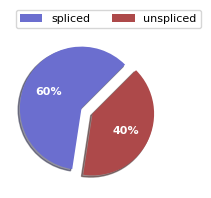

In [146]:
scv.pl.proportions(adata)

In [126]:
import scanpy as sc

In [130]:
sc.pp.pca(adata)
sc.pp.neighbors(adata,n_neighbors=30,n_pcs=0)
sc.tl.umap(adata,min_dist=0.05)
sc.tl.leiden(adata)

In [131]:
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [132]:
scv.tl.velocity(adata, mode='deterministic')

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [141]:
velocity.shape

(500, 200)

In [94]:
from scipy.stats import pearsonr, spearmanr, ttest_ind

In [157]:
velocity = adata.layers['velocity']
velocity_2 = adata_dict['adata_n_c_800obs_299genes_dynamical'].layers['velocity']

In [144]:
a= pearson_correlation_matrices(true_velocity,velocity, mode= 'by_column')

In [145]:
np.mean(a)

0.7750444965354123

In [173]:
b= cosine_similarity_matrices(true_velocity,velocity,mode='by_row')

In [ ]:
a = np.where(np.isnan(b))

(array([  3,   7,   8,  10,  11,  12,  17,  20,  22,  31,  33,  35,  36,
         38,  52,  55,  56,  57,  59,  65,  66,  68,  71,  72,  73,  81,
         83,  85,  88,  89,  93,  94,  96, 100, 103, 105, 106, 109, 111,
        114, 117, 118, 120, 123, 129, 132, 133, 135, 138, 142, 144, 149,
        151, 153, 155, 156, 158, 161, 163, 164, 165, 167, 172, 176, 177,
        182, 187, 188, 193, 194, 197, 200, 201, 207, 208, 211, 215, 219,
        221, 222, 227, 228, 233, 234, 236, 239, 241, 243, 248, 250, 253,
        255, 259, 263, 268, 273, 274, 275, 276, 278, 279, 283, 285, 289,
        291, 294, 296, 297, 298], dtype=int64),)

In [159]:
np.mean(b)

nan

In [96]:
corr_df_velocity = pd.DataFrame(columns=["EM", "VI"], index=np.arange(len(adata.var_names)))

for var_id in range(len(adata.var_names)):
    x = adata.layers["velocity"][:, var_id]
    y = true_velocity[:, var_id]
    corr_df_velocity.loc[var_id, "EM"] = pearsonr(x, y)[0]

In [101]:
corr_df_velocity['EM'].mean()

0.4635017127796958

In [ ]:
for k, adata in adata_dict.items():
    adata_dict[adata].layers['unspliced'] * adata_dict['adata'].var['true_beta']

# Further plot for analysis- gene simulation 

In [179]:
adata_dict['adata_n_c_800obs_299genes_deterministic'].var['true_t_'].max()

82.8681676267105

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your sorted data arrays
def plot_gene_counts(n_obs: None, n_var : None, gene : 0):
    adata = adata_dict[f'adata_n_c_{n_obs}obs_{n_var}genes_deterministic']
    unspliced = adata.layers['unspliced'][:,gene]- adata.layers['spliced_nuc'][:,gene] 
    spliced_nuc = adata.layers['spliced_nuc'][:,gene]
    spliced_cyto = adata.layers['spliced'][:,gene]

    t_max = adata.obs['true_t'].max()

    # Assuming the x-values are indices or known values
    x_values = np.arange(len(unspliced))
    scaling_factor = t_max / n_obs
    x_values_scaled = x_values * scaling_factor

    # Define a function for moving average smoothing
    def moving_average(y, window_size):
        return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

    # Set the window size for smoothing
    window_size = 15  # Adjust the window size as needed

    # Calculate the moving averages for each dataset
    smooth_data1 = moving_average(unspliced, window_size)
    smooth_data2 = moving_average(spliced_nuc, window_size)
    smooth_data3 = moving_average(spliced_cyto, window_size)

    smooth_x_values = x_values[:len(smooth_data1)] + (window_size // 2)
    smooth_x_values_scaled = smooth_x_values * scaling_factor

    # Plot the smooth lines for each dataset using scaled x-values
    plt.plot(smooth_x_values_scaled, smooth_data1, color='blue', linewidth=2, label='unspliced')
    plt.plot(smooth_x_values_scaled, smooth_data2, color='red', linewidth=2, label='spliced nucleic')
    plt.plot(smooth_x_values_scaled, smooth_data3, color='green', linewidth=2, label='spliced cytoplasmic')


    true_t = adata.var['true_t_'][gene] 


    # Draw the vertical line using the scaled x-value
    plt.axvline(x=true_t, color='black', linestyle='--', linewidth=1, label='switch time')

    # Add labels and title
    plt.xlabel('Time')
    plt.ylabel('Abundances')
    plt.title('RNA abundances change over time')
    plt.legend(loc = 'upper right',fontsize = 8)
    plt.grid(True)

    # Display the plot
    plt.show()


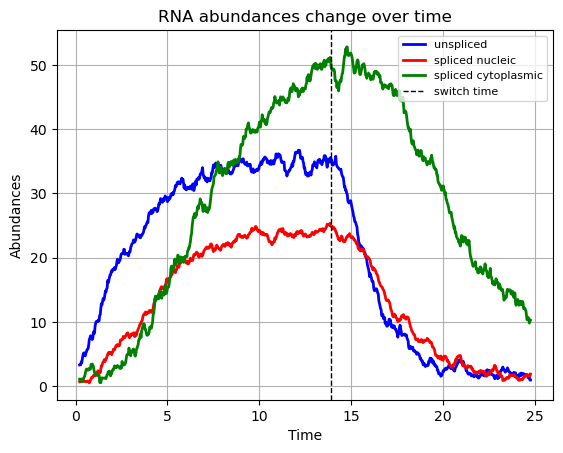

In [36]:
plot_gene_counts(n_obs=800,n_var=300,gene=120)

In [ ]:
54.159129	70.313750	1.904799	3.990005	3.548132	1.0	772	1.021699	1.021699	0.926665

In [227]:
70/3.5

20.0

In [226]:
70/4

17.5

In [225]:
70/1.9

36.8421052631579

In [9]:
adata = adata_dict['adata_n_c_800obs_300genes_dynamical']
adata_2 = adata_dict['adata_n_c_800obs_300genes_velovi']

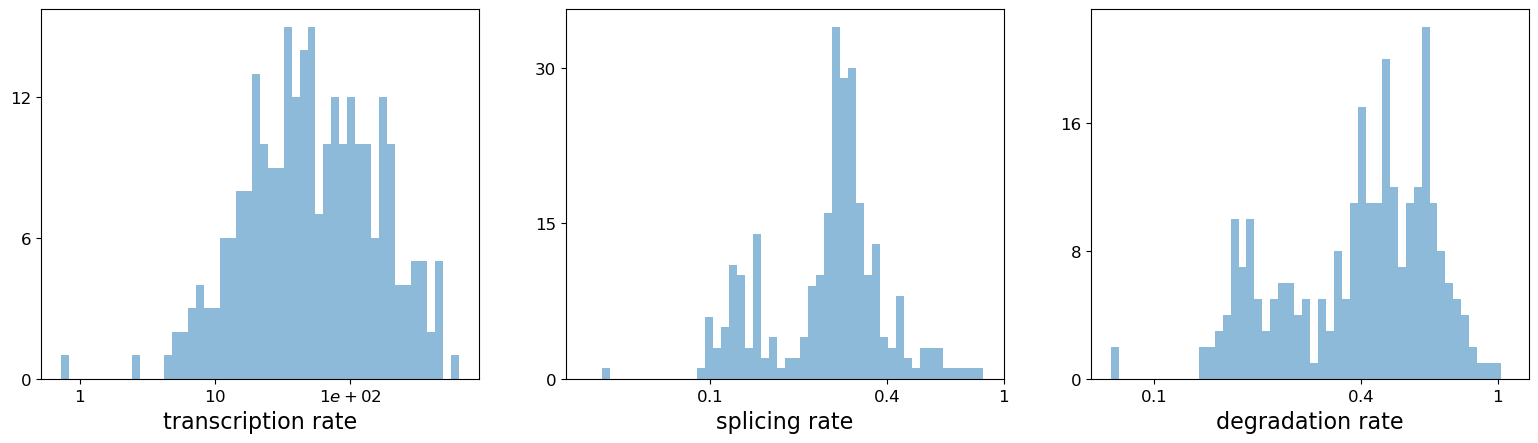

,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
0,0.947685,78.892905,0.396832,0.476532,13.310665,0.571928,72.172874,56.786503,1.066159,0.0,0.0,0.498403,187.272808,150.313407,0.047913,1.982734
1,0.867178,226.230347,0.601453,0.765434,13.627937,0.629199,112.019257,84.121399,0.682976,0.0,0.0,0.498625,367.827794,283.013365,0.192942,1.189111
2,0.952033,81.563627,1.001864,0.834815,12.657267,0.396956,30.544258,34.625793,1.062409,0.0,0.0,0.497243,80.504823,93.171358,0.050733,1.131518
3,0.913156,8.187336,0.035167,0.483377,10.351687,8.599413,80.022118,4.652766,0.813359,0.0,0.0,0.492332,231.212267,13.562099,0.071543,1.736044
4,0.969630,16.473735,0.086666,0.321895,18.267079,5.378562,81.095314,17.854284,0.567693,0.0,0.0,0.496719,203.005373,43.855465,0.173006,2.419404


In [12]:
df = adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(adata, 'fit*', dropna=True).head()

In [13]:
df

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,fit_r2,fit_alpha,fit_beta,...,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling,velocity_genes
0,38.232634,199.130635,2.229647,1.851729,1.291858,1.0,752,0.947685,78.892905,0.396832,...,56.786503,1.066159,0.0,0.0,0.498403,187.272808,150.313407,0.047913,1.982734,True
1,48.473325,219.261612,1.244513,1.104662,0.772268,1.0,767,0.867178,226.230347,0.601453,...,84.121399,0.682976,0.0,0.0,0.498625,367.827794,283.013365,0.192942,1.189111,True
2,41.504610,104.177984,2.128359,3.014790,1.103346,1.0,738,0.952033,81.563627,1.001864,...,34.625793,1.062409,0.0,0.0,0.497243,80.504823,93.171358,0.050733,1.131518,True
5,44.289003,435.872751,4.368890,1.182588,0.807082,1.0,759,0.889901,423.866123,0.897849,...,183.133484,1.025309,0.0,0.0,0.499393,447.346964,537.771665,0.053412,1.298691,True
6,31.303587,64.908867,1.635486,0.479241,2.160695,1.0,756,0.965912,8.462438,0.043273,...,11.159791,0.862175,0.0,0.0,0.495459,161.045004,28.115837,0.064980,4.092717,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,17.990758,126.678299,0.365851,0.494462,1.393540,1.0,748,0.899076,52.309879,0.087155,...,27.113899,0.743072,0.0,0.0,0.499216,442.499310,52.266061,0.093245,1.682057,True
296,10.190701,95.226863,1.714429,0.898292,1.139212,1.0,715,0.950541,40.916002,0.269592,...,23.913658,0.679478,0.0,0.0,0.499444,143.745445,67.213812,0.106659,1.660873,True
297,57.655704,182.487705,1.705067,2.087826,1.485469,1.0,777,0.857197,36.326702,0.174649,...,22.936205,0.287966,0.0,0.0,0.494352,188.492006,116.227097,0.698538,3.452644,True
298,64.590633,306.261010,1.994270,4.013386,2.293842,1.0,778,0.727462,39.601039,0.162066,...,20.992708,0.260761,0.0,0.0,0.490531,228.140158,132.364460,0.861057,3.803473,True


In [104]:
df_2 = scv.get_df(adata_2, 'fit*', dropna=True).head()

In [109]:
adata_2

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'spearmans_score', 'velocity_score'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'fit_t', 'latent_time_velovi', 'spliced', 'spliced_nuc', 'true_velocity', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'

In [108]:
df_2

,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling
0,0.285366,0.315427,0.319966,15.111290,1.0
1,0.324825,0.355882,0.375632,14.144192,1.0
2,0.340708,0.381818,0.372942,13.750994,1.0
3,0.303804,0.348542,0.334934,14.477716,1.0
4,0.319214,0.364773,0.362476,12.150274,1.0


In [101]:
df[['true_t_','fit_t_']]

,true_t_,fit_t_
0,38.232634,13.310665
1,48.473325,13.627937
2,41.504610,12.657267
5,44.289003,11.347119
6,31.303587,22.485876
...,...,...
295,17.990758,8.581597
296,10.190701,8.859769
297,57.655704,13.819764
298,64.590633,15.203607
